<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
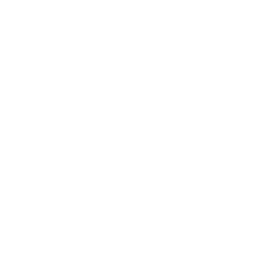
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identyfikacja reżimów rynkowych</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanse ilościowe / Zarządzanie aktywami &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie dla kierownictwa

Ten przykład wykorzystuje **PROC ACECLUS** do znalezienia ukrytej struktury, która rozdziela reżimy rynkowe, a następnie grupuje na jej podstawie. Ze 100 tygodniowych obserwacji 10 cech rynkowych (stopa zwrotu i zmienność akcji, spready kredytowe i wysokodochodowe, krzywa 2y/10y, dolar, surowce oraz zmiana VIX) ACECLUS estymuje przybliżoną kowariancję wewnątrz reżimu *bez* użycia jakiejkolwiek etykiety reżimu i wyprowadza zmienne kanoniczne, wzdłuż których reżimy się rozdzielają.

Przy progu P=0.02 algorytm zbiega w dwóch iteracjach i zachowuje **trzy wymiary kanoniczne**, które łącznie wyjaśniają cały rozrzut między reżimami (proporcje wartości własnych 57.8%, 24.4%, 17.8%). Luźniejszy próg P=0.05 nadmiernie wygładza kowariancję i **redukuje strukturę do pojedynczego wymiaru** — pożyteczne ostrzeżenie, że próg istotnie kształtuje wynik.

Wprowadzenie trzech zmiennych kanonicznych do **PROC FASTCLUS** (k=4) daje czyste uporządkowanie 100 tygodni według nasilenia stresu (ogólne R² = 0.51, pseudo F = 33.2): 62-tygodniowy spokojny rdzeń, 22-tygodniowa grupa odbicia/łagodnienia zmienności, 12-tygodniowa grupa podwyższonego stresu oraz 4-tygodniowa grupa głębokiego kryzysu ze spreadami wysokodochodowymi wynoszącymi średnio ~1,514 bps. Te przypisania są eksportowane do dalszego warunkowania ryzyka portfela.


## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Tygodniowe obserwacje cech rynkowych w różnych klasach aktywów | 100 |
| Zmienne: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Szereg jest generowany przez pięciostanowy proces Markowa z przełączaniem reżimów (hossa/ekspansja, późny cykl, risk-off, kryzys, ożywienie) z rozkładami cech warunkowanymi reżimem. Uruchomiony bez licencji, tabela cech jest ograniczona do pierwszych 100 tygodniowych obserwacji (~2 lata) — okna zdominowanego przez hossę, które odwiedza także krótki kryzys i ożywienie. Tygodniowe stopy zwrotu i zmiany poziomów zastępują ruchy cen na koniec tygodnia; spready są wyrażone w punktach bazowych, a zmienność jest indeksem typu VIX.


---

In [1]:
/* --------------------------------------------------------
   Generuje tygodniową, wieloaktywową historię rynku z
   pięcioma ukrytymi reżimami sterowanymi procesem
   przełączania Markowa. Ten przykład działa bez licencji,
   więc tabela cech poniżej jest ograniczona do pierwszych
   100 obserwacji tygodniowych (~2 lata) -- okno zdominowane
   przez hossę, przerwane krótkim kryzysem i ożywieniem.
   -------------------------------------------------------- */
DANE work.market_weekly;
    CALL streaminit(42);
    /* 5 reżimów: 1=Hossa, 2=Późny cykl, 3=Ucieczka od ryzyka, 4=Kryzys, 5=Ożywienie */
    DŁUGOŚĆ regime_label $32;
    TABLICA regime_names[5] $32 _temporary_
        ('Hossa' 'Późny cykl' 'Ucieczka od ryzyka'
         'Kryzys' 'Ożywienie');
    PRZECHOWAJ current_regime 1;
    POWTÓRZ week_id = 1 TO 5000;
        /* przełączanie reżimów Markowa */
        u = rand('uniform');
        JEŚLI current_regime = 1 WTEDY POWTÓRZ; /* Hossa: długotrwała */
            JEŚLI u > 0.97 WTEDY current_regime = 2;
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 2 WTEDY POWTÓRZ; /* Późny cykl */
            JEŚLI u > 0.92 WTEDY current_regime = 3;
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 3 WTEDY POWTÓRZ; /* Ucieczka od ryzyka */
            JEŚLI u > 0.80 WTEDY current_regime = 4;
            PRZECIWNIE JEŚLI u < 0.10 WTEDY current_regime = 1;
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 4 WTEDY POWTÓRZ; /* Kryzys: krótki */
            JEŚLI u > 0.75 WTEDY current_regime = 5;
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 5 WTEDY POWTÓRZ; /* Ożywienie */
            JEŚLI u > 0.85 WTEDY current_regime = 1;
        KONIEC;
        regime_label = regime_names[current_regime];
        /* rozkłady cech warunkowe względem reżimu */
        JEŚLI current_regime = 1 WTEDY POWTÓRZ;  /* Hossa */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 2 WTEDY POWTÓRZ;  /* Późny cykl */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 3 WTEDY POWTÓRZ;  /* Ucieczka od ryzyka */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        KONIEC;
        PRZECIWNIE JEŚLI current_regime = 4 WTEDY POWTÓRZ;  /* Kryzys */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        KONIEC;
        PRZECIWNIE POWTÓRZ;  /* Ożywienie */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        KONIEC;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        JEŚLI week_id = 1 WTEDY vix_chg = 0;
        WYJŚCIE;
    KONIEC;
    USUŃ u;
    PRZEMIANUJ credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
WYKONAJ;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.32 seconds
  cpu   1.32 seconds


---

In [2]:
/* --------------------------------------------------------
   Bazowe rozkłady cech rynkowych według reżimu
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.market_weekly n mean std MIN MAX;
    KLASA regime_label;
    ZMIENNA eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETYKIETA regime_label="Reżim rynkowy"
          eq_return_pct="Tygodniowa stopa zwrotu akcji (%)"
          eq_vol_idx="Indeks zmienności akcji"
          credit_spread_bps="Spread kredytowy (pb)"
          hy_spread_bps="Spread high-yield (pb)"
          term_spread="Spread terminowy"
          vix_chg="Zmiana VIX";
    TYTUŁ "Bazowe rozkłady cech rynkowych według reżimu";
WYKONAJ;
TYTUŁ;

                                      Bazowe rozkłady cech rynkowych według reżimu                                      

                                                  The MEANS Procedure

                          Analysis Variable : eq_return_pct Tygodniowa stopa zwrotu akcji (%)

        Reżim rynkowy               N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------
        Hossa                          28      0.2860000      1.0226518     -1.5980000      2.2150000
        Kryzys                         12     -2.3403333      3.9436692     -8.0160000      3.7360000
        Ożywieni                        4      0.0077500      1.5951747     -0.8330000      2.4000000
        Późny cy                       39      0.0364359      1.9733801     -4.6010000      3.7030000
        Ucieczka od ryzyka             17     -0.8447059      1.2832441     -3.3850000      1.181000


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


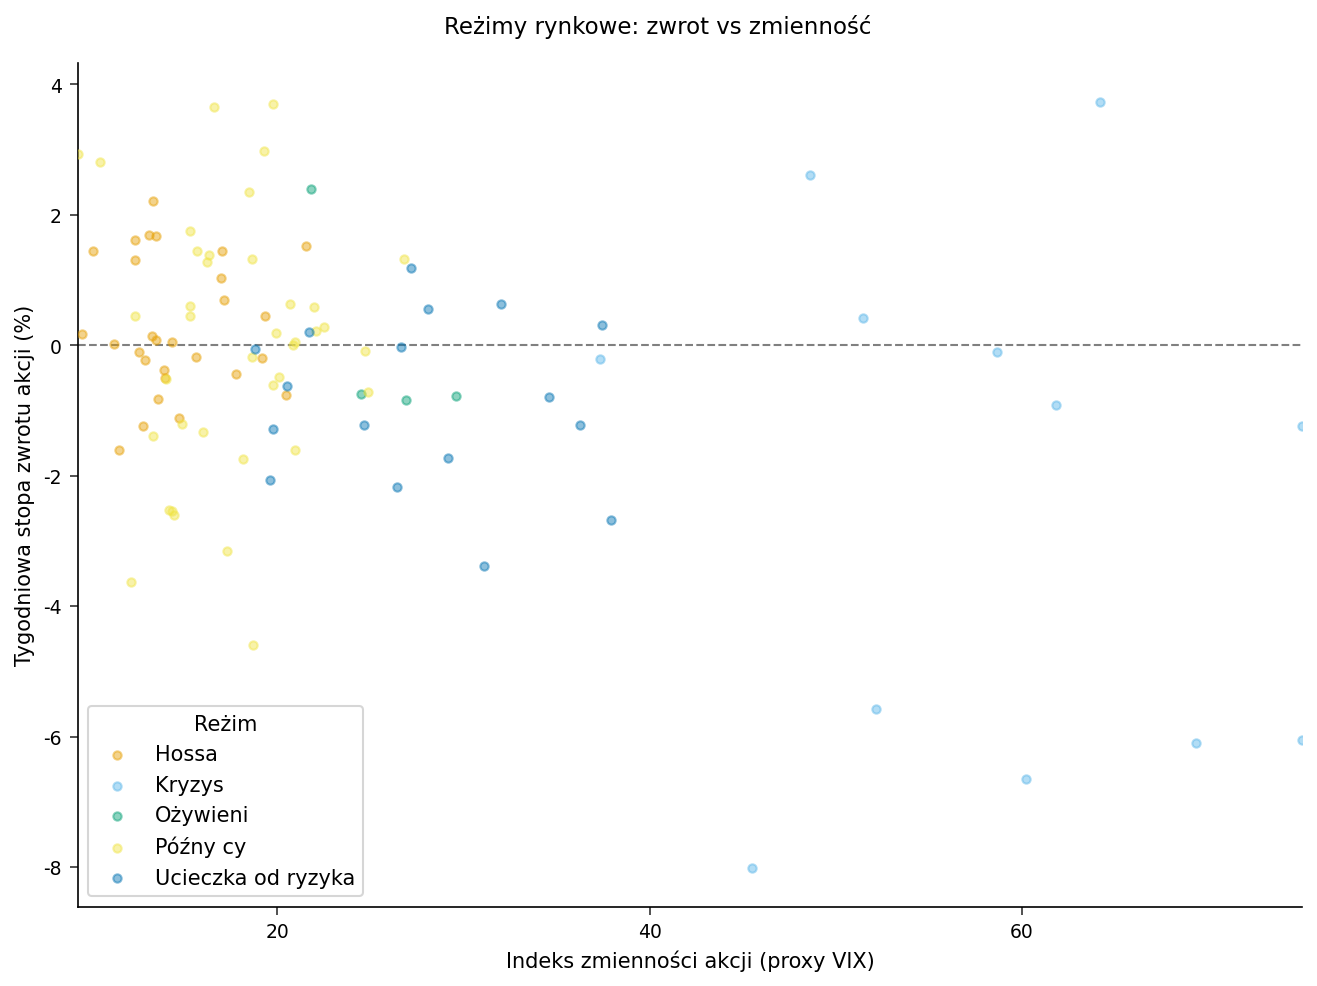

In [3]:
/* --------------------------------------------------------
   Zwrot z akcji vs indeks zmienności według reżimu
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ETYKIETA='Indeks zmienności akcji (proxy VIX)';
    YAXIS ETYKIETA='Tygodniowa stopa zwrotu akcji (%)';
    keylegend / TYTUŁ='Reżim';
    TYTUŁ 'Reżimy rynkowe: zwrot vs zmienność';
WYKONAJ;

---

In [4]:
/* --------------------------------------------------------
   Przybliżona estymacja kowariancji wewnątrz reżimu.
   ACECLUS estymuje połączoną kowariancję wewnątrzklastrową
   bez znajomości etykiet klastrów, a następnie wyprowadza
   zmienne kanoniczne rozdzielające reżimy. P=0.02 ustawia
   próg odległości parami: tylko najbliższe ~2% par
   obserwacji traktuje się jako ten sam reżim.
   -------------------------------------------------------- */
PROCEDURA aceclus DANE=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    ZMIENNA eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    TYTUŁ "ACECLUS: kowariancja kanoniczna (P=0.02)";
WYKONAJ;
TYTUŁ;

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Kontrola wrażliwości przy P=0.05 -- luźniejszy próg tego
   samego reżimu wciąga więcej par, zawyżając szacowaną
   kowariancję wewnątrz reżimu. Porównaj strukturę
   kanoniczną (wartości własne i zachowane wymiary)
   z rozwiązaniem P=0.02.
   -------------------------------------------------------- */
PROCEDURA aceclus DANE=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    ZMIENNA eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    TYTUŁ "ACECLUS: kowariancja kanoniczna (P=0.05)";
WYKONAJ;
TYTUŁ;

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-średnich na zmiennych kanonicznych ACECLUS. ACECLUS
   zachował trzy wymiary kanoniczne (Can1-Can3), więc
   grupowanie działa na nich. Cztery klastry celują w cztery
   dobrze zaludnione stany rynku.
   -------------------------------------------------------- */
PROCEDURA FASTCLUS DANE=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    ZMIENNA can1 can2 can3;
    TYTUŁ "FASTCLUS: cztery klastry na zmiennych kanonicznych";
WYKONAJ;
TYTUŁ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                      Klaster reżimu vs rzeczywisty reżim rynkowy                                       

                                                   The FREQ Procedure

Table of Klaster by Reżim rynkowy

Klaster |             Hossa |            Kryzys |          Ożywieni |          Późny cy |Ucieczka od ryzyka |              Total
--------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
1       |                 2 |                 4 |                 0 |                 2 |                 4 |                 12
        |              2.00 |              4.00 |              0.00 |              2.00 |              4.00 |              12.00
--------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
2       |                21 |                 3 |                 3 |                28 |                 7 |                 6


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


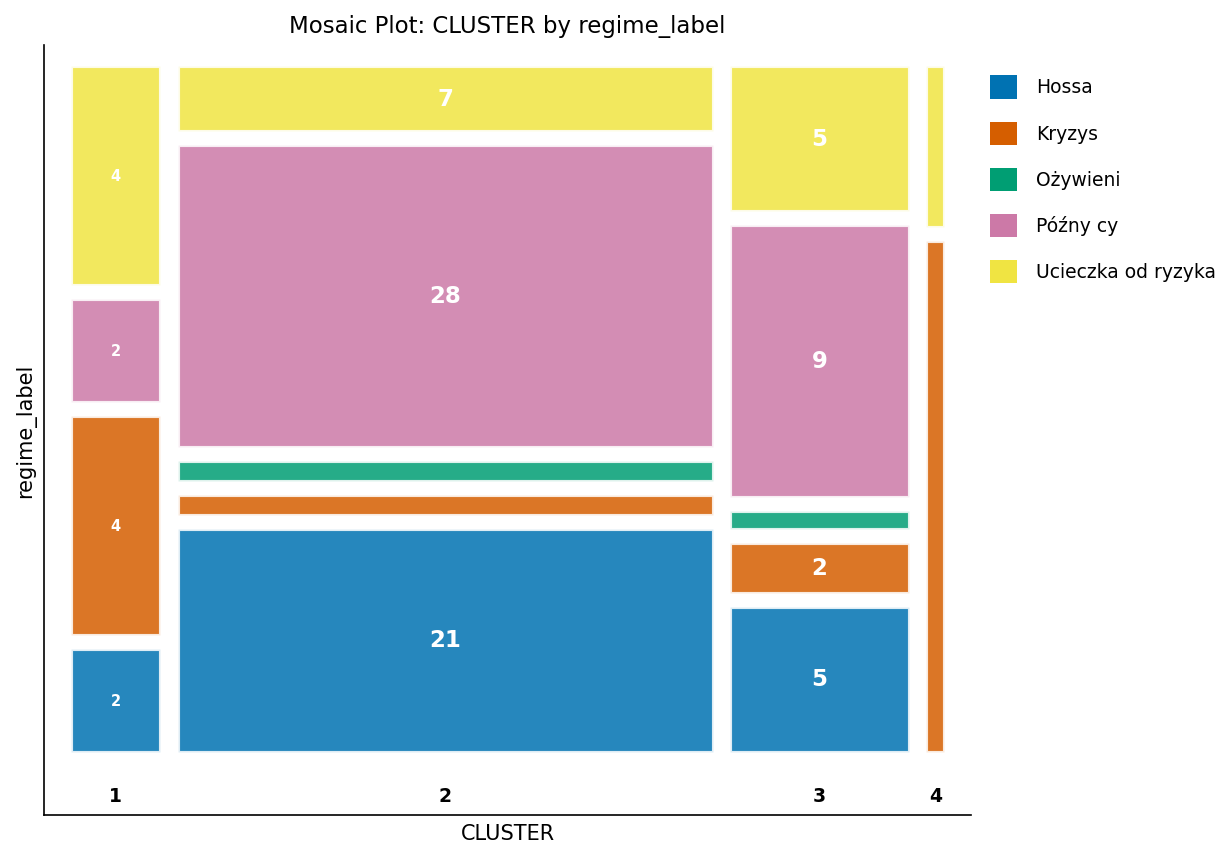

In [7]:
/* --------------------------------------------------------
   Walidacja przypisanych klastrów względem znanych
   etykiet reżimów z generowania danych
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    ETYKIETA CLUSTER="Klaster" regime_label="Reżim rynkowy";
    TYTUŁ 'Klaster reżimu vs rzeczywisty reżim rynkowy';
WYKONAJ;
TYTUŁ;

In [8]:
/* --------------------------------------------------------
   Profil średnich cech reżimu do interpretacji
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.regime_assignments mean;
    KLASA CLUSTER;
    ZMIENNA eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETYKIETA CLUSTER="Klaster"
          eq_return_pct="Tygodniowa stopa zwrotu akcji (%)"
          eq_vol_idx="Indeks zmienności akcji"
          credit_spread_bps="Spread kredytowy (pb)"
          hy_spread_bps="Spread high-yield (pb)"
          term_spread="Spread terminowy"
          vix_chg="Zmiana VIX";
    TYTUŁ "Profil średnich cech według klastra";
WYKONAJ;
TYTUŁ;

                                          Profil średnich cech według klastra                                           

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Tygodniowa stopa zwrotu akcji (%)

                                                          N
                                             Klaster    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Indeks zmienności akcji



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretacja

**Struktura kanoniczna ACECLUS.** Na próbie 100 tygodni PROC ACECLUS (P=0.02, próg = 2.578941) zbiegł w dwóch iteracjach i wytworzył trzy zmienne kanoniczne. Ich wartości własne `Inv(ACE)*(COV-ACE)` wynoszą 0.0219, 0.0093 i 0.0067, tj. proporcje 57.8%, 24.4% i 17.8% (skumulowanie 100%). Pierwsza oś kanoniczna niesie dominujący kontrast risk-on/risk-off; druga i trzecia go doprecyzowują. Ponieważ cechy zmienności akcji i spreadów silnie się współporuszają, ACECLUS włącza tę wspólną zmienność do kowariancji wewnątrz reżimu, tak że osie kanoniczne odzwierciedlają rzeczywiste rozdzielenie między reżimami, a nie wspólną skalę.

**Wrażliwość na próg.** Ponowne uruchomienie przy P=0.05 podnosi próg odległości do 2.899704, co wciąga 4,949 z 4,950 par obserwacji poniżej odcięcia. Estymowana kowariancja wewnątrz reżimu niemal równa się wówczas kowariancji całkowitej, a struktura kanoniczna **redukuje się do pojedynczego wymiaru** (jedna wartość własna, 0.0096, przy 100%). Rozwiązania P=0.02 i P=0.05 nie są zatem *wymienne* w tym przypadku — luźniejszy próg wymazuje subtelniejsze osie reżimów, więc ciaśniejszy próg jest bardziej informatywną specyfikacją dla tej próby.

**Grupowanie na zmiennych kanonicznych.** PROC FASTCLUS (k=4) na Can1–Can3 daje ogólne R² równe 0.5089 i pseudo F równe 33.16. Can2 wykonuje większość pracy rozdzielającej (R² = 0.626), Can1 wnosi umiarkowany wkład (R² = 0.359), a Can3 nie dodaje praktycznie nic (R² = 0.000) — zgodnie z tym, że tylko dwie osie niosą silny sygnał. Cztery skupienia układają się w gradient stresu rynkowego:

| Skupienie | n | Śr. stopa zwrotu akcji | Śr. VIX | Śr. spread HY | Śr. zmiana VIX | Odczyt |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Spokojny rdzeń (hossa / późny cykl) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Ożywienie, spadająca zmienność |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Podwyższony stres, skok zmienności |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Głęboki kryzys, ekstremalny stres kredytowy |

**Skupienie a rzeczywisty reżim.** Tabela krzyżowa pokazuje, że skupienia nie odwzorowują się jeden do jednego na pięć etykiet generujących — co jest oczekiwane, ponieważ etykiety silnie się nakładają w przestrzeni cech przy tej wielkości próby. Duże spokojne skupienie (62) absorbuje większość tygodni hossy (21) i późnego cyklu (28); skupienie głębokiego kryzysu (4) to niemal wyłącznie najbardziej ekstremalne tygodnie kryzysu (3 z 4). Osie kanoniczne organizują zatem tygodnie według *nasilenia*, a nie według dokładnej etykiety, co jest sygnałem bardziej użytecznym dla warunkowania ryzyka.

**Zastosowanie.** Wyeksportowane tygodniowe przypisania wspierają warunkowanie taktyczne: zmniejszaj ryzyko i wydłużaj duration, gdy tygodnie migrują ku Skupieniom 1 i 4, oraz ponownie zwiększaj ryzyko, gdy wracają do spokojnego rdzenia (Skupienie 2) lub grupy ożywienia (Skupienie 3).


---

In [9]:
/* --------------------------------------------------------
   Eksport tygodniowych przypisań reżimów do warunkowania
   modelu ryzyka portfela i generowania sygnałów
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Zasilane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>